# WIP

In [1]:
from macrohet import dataio, tile
from pathlib import Path
import napari
import numpy as np

In [3]:
base_dir = '/mnt/OPERA2/Baptiste/20250808_ND_Test_zstack/20250808_ND-test_zstack__2025-08-08T16_38_15-Measurement 1'

In [4]:
metadata = dataio.read_harmony_metadata(Path(base_dir, 'Images/Index.idx.xml'))

Reading metadata XML file...


0it [00:00, ?it/s]

Extracting metadata complete!


In [5]:
metadata

,id,State,URL,Row,Col,FieldID,PlaneID,TimepointID,ChannelID,FlimID,...,PositionZ,AbsPositionZ,MeasurementTimeOffset,AbsTime,MainExcitationWavelength,MainEmissionWavelength,ObjectiveMagnification,ObjectiveNA,ExposureTime,OrientationMatrix
0,0303K1F1P1R1,Ok,r03c03f01p01-ch1sk1fk1fl1.tiff,3,3,1,1,0,1,1,...,-5E-06,0.135291502,0,2025-08-08T16:38:29.853+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
1,0303K1F1P1R2,Ok,r03c03f01p01-ch2sk1fk1fl1.tiff,3,3,1,1,0,2,1,...,-5E-06,0.135291502,0,2025-08-08T16:38:30.197+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
2,0303K1F1P2R1,Ok,r03c03f01p02-ch1sk1fk1fl1.tiff,3,3,1,2,0,1,1,...,-4E-06,0.1352925,0,2025-08-08T16:38:30.477+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
3,0303K1F1P2R2,Ok,r03c03f01p02-ch2sk1fk1fl1.tiff,3,3,1,2,0,2,1,...,-4E-06,0.1352925,0,2025-08-08T16:38:30.743+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
4,0303K1F1P3R1,Ok,r03c03f01p03-ch1sk1fk1fl1.tiff,3,3,1,3,0,1,1,...,-3E-06,0.135293499,0,2025-08-08T16:38:31.023+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232645,0404K97F16P23R2,Ok,r04c04f16p23-ch2sk97fk1fl1.tiff,4,4,16,23,96,2,1,...,1.7E-05,0.135240495,172803.576,2025-08-10T16:49:50.647+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
232646,0404K97F16P24R1,Ok,r04c04f16p24-ch1sk97fk1fl1.tiff,4,4,16,24,96,1,1,...,1.8E-05,0.135241494,172803.576,2025-08-10T16:49:50.91+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
232647,0404K97F16P24R2,Ok,r04c04f16p24-ch2sk97fk1fl1.tiff,4,4,16,24,96,2,1,...,1.8E-05,0.135241494,172803.576,2025-08-10T16:49:51.19+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
232648,0404K97F16P25R1,Ok,r04c04f16p25-ch1sk97fk1fl1.tiff,4,4,16,25,96,1,1,...,1.9E-05,0.135242507,172803.576,2025-08-10T16:49:51.457+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."


In [6]:
metadata[['Row', 'Col']].drop_duplicates()

,Row,Col
0,3,3
800,3,4
1600,4,4


In [7]:
metadata['ImageResolutionX'].unique()

array(['1.4949402023919043E-07'], dtype=object)

In [8]:
metadata['PositionZ'].unique()

array(['-5E-06', '-4E-06', '-3E-06', '-2E-06', '-1E-06', '0', '1E-06',
       '2E-06', '3E-06', '4E-06', '5E-06', '6E-06', '7E-06', '8E-06',
       '9E-06', '1E-05', '1.1E-05', '1.2E-05', '1.3E-05', '1.4E-05',
       '1.5E-05', '1.6E-05', '1.7E-05', '1.8E-05', '1.9E-05'],
      dtype=object)

In [9]:
image_dir = Path(base_dir, 'Images')
images = tile.compile_mosaic(str(image_dir), metadata, row=3, col=3,  n_tile_cols=4, n_tile_rows=4)

In [10]:
images

dask.array<reshape, shape=(97, 2, 25, 7992, 7992), dtype=uint16, chunksize=(1, 1, 1, 2160, 2160), chunktype=numpy.ndarray>

In [11]:
 # scale = (1.0, 0.14949402023919043, 0.14949402023919043)
scale = (1,1,1)

In [27]:
viewer = napari.Viewer(title = 'deep Z stack')

viewer.add_image(images, channel_axis = 1, scale = scale)

[<Image layer 'Image' at 0x756ebff73460>,
 <Image layer 'Image [1]' at 0x756ea0380c40>]

In [30]:
viewer.scale_bar.visible = True
viewer.scale_bar.unit = "µm"       # units displayed on bar
viewer.scale_bar.position = "bottom_right"  # other options: top_left, bottom_left, top_right
viewer.scale_bar.colored = False    # use layer colormap for scalebar color

Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/app/backends/_qt.py", line 963, in paintGL
    self._vispy_canvas.events.draw(region=None)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 453, in __call__
    self._invoke_callback(cb, event)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 471, in _invoke_callback
    _handle_exception(self.ignore_callback_errors,
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 469, in _invoke_callback
    cb(event)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/scene/canvas.py", line 219, in on_draw
    self._draw_scene()
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/scene/canvas.py", line 278, in _draw_scene
    self.draw_visual(self.scene)
  File "/home/dayn/miniconda3/

# Segment


In [12]:
import napari
import numpy as np
import zarr

from tqdm.auto import tqdm



Welcome to CellposeSAM, cellpose v4.0.1! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [13]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available.")

GPU is available!
Device name: NVIDIA RTX A6000


In [14]:
%%time
segmentation_input = images[0,-1,:,...]
segmentation_input.shape

CPU times: user 25.2 ms, sys: 873 μs, total: 26.1 ms
Wall time: 25.5 ms


(25, 7992, 7992)

In [15]:
%%time

segmentation_input = segmentation_input.compute().compute()

CPU times: user 20min 29s, sys: 1min 43s, total: 22min 13s
Wall time: 1min 58s


In [16]:
scale = (1.0, 0.14949402023919043, 0.14949402023919043)

In [17]:
anistropy = 1/0.14949402023919043

In [39]:
viewer.add_image(segmentation_input, scale = scale)

<Image layer 'segmentation_input' at 0x756d68413580>

In [16]:
model = models.CellposeModel(gpu=True)

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cpsam


In [17]:
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

INFO:cellpose.core:** TORCH CUDA version installed and working. **


# First attempt (failed at 90%)

In [ ]:
%%time

flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0
batch_size = 128
masks, flows, styles = model.eval(segmentation_input, 
                                  z_axis=0, do_3D=True,
                                  progress=True,
                                  batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

INFO:cellpose.core:running YX: 25 planes of size (7992, 7992)
INFO:cellpose.core:100%|##########| 25/25 [25:43<00:00, 61.75s/it]
INFO:cellpose.core:running ZY: 7992 planes of size (25, 7992)
INFO:cellpose.core:90%|########9 | 7153/7992 [6:07:59<50:20,  3.60s/it]


# Subsample (segment over cropped region)

In [20]:
segmentation_input.shape

(25, 7992, 7992)

In [21]:
viewer = napari.Viewer(title='quick view of FOV')
viewer.add_image(segmentation_input)

<Image layer 'segmentation_input' at 0x761a0ce19780>

In [22]:
viewer.add_image(segmentation_input[:,0:2000,0:2000])

<Image layer 'Image' at 0x761979a6b460>

In [24]:
cropped_segmentation_input = segmentation_input[:,0:2000,0:2000]
cropped_segmentation_input.shape

(25, 2000, 2000)

In [25]:
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0
batch_size = 128
masks, flows, styles = model.eval(cropped_segmentation_input, 
                                  z_axis=0, do_3D=True,
                                  progress=True,
                                  batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

INFO:cellpose.core:running YX: 25 planes of size (2000, 2000)
INFO:cellpose.core:100%|##########| 25/25 [01:44<00:00,  4.17s/it]
INFO:cellpose.core:running ZY: 2000 planes of size (25, 2000)
INFO:cellpose.core:100%|##########| 334/334 [26:34<00:00,  4.77s/it]
INFO:cellpose.core:running ZX: 2000 planes of size (25, 2000)
INFO:cellpose.core:100%|##########| 334/334 [26:10<00:00,  4.70s/it]
INFO:cellpose.models:network run in 3274.62s
INFO:cellpose.models:masks created in 7.33s


In [27]:
viewer.add_labels(masks, scale = scale)

<Labels layer 'masks' at 0x761980cf30d0>

In [28]:
for layer in viewer.layers:
    layer.scale = scale

INFO:OpenGL.acceleratesupport:No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/app/backends/_qt.py", line 963, in paintGL
    self._vispy_canvas.events.draw(region=None)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 453, in __call__
    self._invoke_callback(cb, event)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 471, in _invoke_callback
    _handle_exception(self.ignore_callback_errors,
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 469, in _invoke_callback
    cb(event)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/scene/canvas.py", line 219, in on_draw
    self._draw_scene()
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/scen

In [26]:
np.save('test.npy', masks)

### Tidy up

In [42]:
from skimage.measure import regionprops, label
from tqdm.auto import tqdm

In [39]:
np.sum(masks[-1] == 1091)

np.int64(1965)

In [41]:
viewer.add_labels(masks[-1] == 1091, scale =(scale[1], scale[2]))

<Labels layer 'Labels [1]' at 0x76192d63a6b0>

### Therefore, minimum size should be 2000

In [59]:
def filter_objects_by_slice_area(masks, min_pixels=2000):
    """
    Keep only objects whose footprint is >= min_pixels in every z-slice they appear.
    
    Parameters
    ----------
    masks : np.ndarray
        3D labeled mask array (Z, Y, X).
    min_pixels : int
        Minimum pixels per slice.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered mask array, same shape as input.
    """
    filtered = np.zeros_like(masks)
    labels = np.unique(masks)
    labels = labels[labels > 0]  # skip background
    
    for lbl in tqdm(labels, desc='iterating over labels'):
        obj = (masks == lbl)
        # collapse along z to check per-slice footprint
        valid = True
        for z in range(masks.shape[0]):
            slice_area = np.sum(obj[z])
            if slice_area > 0 and slice_area < min_pixels:
                valid = False
                break
        if valid:
            filtered[obj] = lbl
    
    return filtered

# Example:
filtered_masks = filter_objects_by_slice_area(masks, min_pixels=200)
print("Kept labels:", np.unique(filtered_masks))

iterating over labels:   0%|          | 0/1579 [00:00<?, ?it/s]

Kept labels: [   0    1    3    4    6    7   12   17   19   22   26   27   33   51
   54   55   68   69   70   73   79   82   85   93  142  144  145  148
  152  164  165  174  176  213  222  236  258  261  262  263  288  290
  298  322  356  369  372  374  375  379  380  381  384  395  434  630
  682  688  689  690  865  880  887  944 1301 1334 1422 1487]


In [60]:
viewer.add_labels(filtered_masks, )#scale = scale)

<Labels layer 'filtered_masks [2]' at 0x761919d5b6a0>

# Try segmenting per z-slice

In [70]:
for layer in viewer.layers:
    layer.scale = (1,1,1)

In [47]:
segmentation_input.shape

(25, 7992, 7992)

In [62]:
np.sum(masks[5] == 229)

np.int64(2183)

In [72]:
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0
batch_size = 128
slice_masks_stack = []

for slice in tqdm(segmentation_input, desc='iterating over z slices'):

    slice_masks, flows, styles = model.eval(slice, 
                                            # min_size=2000, diameter = 100,
                                      # z_axis=0, do_3D=True,
                                      # progress=True,
                                      # batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                      # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                           )
    slice_masks_stack.append(slice_masks)
slice_masks_stack = np.stack(slice_masks_stack, axis = 0)

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

In [73]:
viewer.add_labels(slice_masks_stack)

<Labels layer 'slice_masks_stack [1]' at 0x76192d563a30>

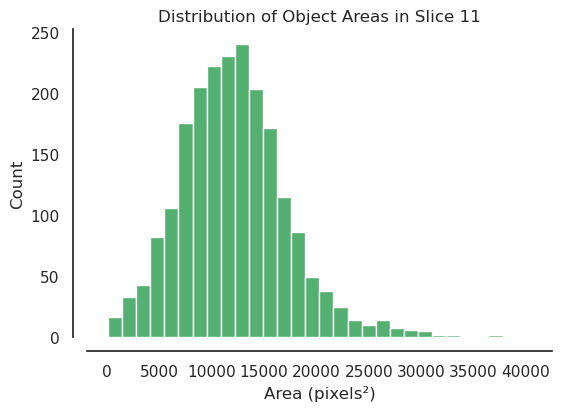

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import regionprops

# Extract one slice (2D)
lbl = slice_masks_stack[11]

# Compute region properties
props = regionprops(lbl)

# Collect areas (in pixels²)
areas = [p.area for p in props]

# Plot distribution
sns.set(style="white", font="Helvetica")
plt.figure(figsize=(6,4))
sns.histplot(areas, bins=30, color="#1a9641", edgecolor=None)
sns.despine(offset=10)
plt.xlabel("Area (pixels²)")
plt.ylabel("Count")
plt.title("Distribution of Object Areas in Slice 11")
plt.show()

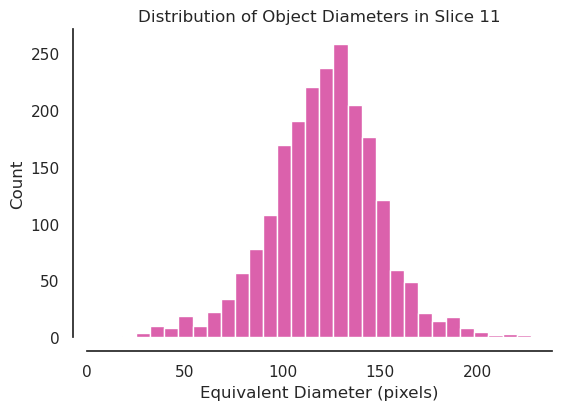

In [75]:
# Extract one slice
lbl = slice_masks_stack[11]

# Region properties
props = regionprops(lbl)

# Collect equivalent diameters (in pixels)
diameters = [p.equivalent_diameter for p in props]

# Plot distribution
sns.set(style="white", font="Helvetica")
plt.figure(figsize=(6,4))
sns.histplot(diameters, bins=30, color="#d02c91", edgecolor=None)
sns.despine(offset=10)
plt.xlabel("Equivalent Diameter (pixels)")
plt.ylabel("Count")
plt.title("Distribution of Object Diameters in Slice 11")
plt.show()


In [83]:
# works for the middle of the z stack
slice_masks, flows, styles = model.eval(segmentation_input[0], 
                                        diameter = 150,
                                       )

In [84]:
viewer.add_labels(slice_masks)

<Labels layer 'slice_masks [3]' at 0x7618ca7b9660>

In [82]:
np.sum(viewer.layers['Labels'].data)

np.uint64(4859)

In [85]:
slice_masks_stack = [model.eval(slice, diameter = 150,)[0] for slice in tqdm(segmentation_input)]

  0%|          | 0/25 [00:00<?, ?it/s]

In [86]:
slice_masks_stack = np.stack(slice_masks_stack, axis = 0)

In [87]:
viewer.add_labels(slice_masks_stack)

<Labels layer 'slice_masks_stack [2]' at 0x7618caf4dd50>

In [93]:
np.save('t0_d150_test_z_stack.npy', slice_masks_stack)

In [19]:
slice_masks_stack = np.load('t0_d150_test_z_stack.npy')

### Load mtb channel to check Z dist

In [20]:
%%time

mtb_frame_1 = images[0,0,:,...].compute().compute()

CPU times: user 20min 55s, sys: 1min 12s, total: 22min 8s
Wall time: 1min 59s


In [21]:
viewer = napari.Viewer(title = 'z seg via tracking')

In [22]:
viewer.add_image(segmentation_input, colormap='green')

<Image layer 'segmentation_input' at 0x79843c2d78b0>

In [23]:
viewer.add_image(mtb_frame_1, colormap='magenta')

<Image layer 'mtb_frame_1' at 0x79843c0ecee0>

In [24]:
viewer.add_labels(slice_masks_stack)

<Labels layer 'slice_masks_stack' at 0x798431f82770>

In [30]:
for layer in viewer.layers:
    layer.scale = (1/0.149, 1, 1)

## Track and unite segments over Z

In [31]:
import trackastra

In [32]:
import torch
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load a pretrained model
model = Trackastra.from_pretrained("ctc", device=device)

/home/dayn/.trackastra/.models/ctc already downloaded, skipping.


INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/trackastra/model/model.py:498: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue

In [33]:
segmentation_input.shape, slice_masks_stack.shape

((25, 7992, 7992), (25, 7992, 7992))

In [35]:
%%time
# # Track the cells
track_graph = model.track(segmentation_input, slice_masks_stack, mode="greedy_nodiv")  # or mode="ilp", or "greedy_nodiv"


# Write to cell tracking challenge format
ctc_tracks, masks_tracked = graph_to_ctc(
      track_graph,
      slice_masks_stack,
      outdir="temp_track_output/",
)

Saving masks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:11<00:00,  2.20it/s]

CPU times: user 40.3 s, sys: 3.9 s, total: 44.2 s
Wall time: 33.5 s


In [76]:

# Write to cell tracking challenge format
ctc_tracks, masks_tracked = graph_to_ctc(
      track_graph,
      slice_masks_stack,
      # outdir=None,
)

Converting graph to CTC results: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2753/2753 [00:03<00:00, 851.19it/s]


In [36]:
viewer.add_labels(masks_tracked)

<Labels layer 'masks_tracked' at 0x79843e7420e0>

# Uniting the two approaches to segment over 3D

In [ ]:
from cellpose import core, models
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks
from macrohet import dataio
from pathlib import Path
segmentation_model = models.CellposeModel(gpu=True)
tracking_model = Trackastra.from_pretrained("ctc", device=device)

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cpsam


/home/dayn/.trackastra/.models/ctc already downloaded, skipping.


INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/trackastra/model/model.py:498: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue

In [ ]:
base_dir = '/mnt/OPERA2/Baptiste/20250808_ND_Test_zstack/20250808_ND-test_zstack__2025-08-08T16_38_15-Measurement 1'

In [4]:
metadata = dataio.read_harmony_metadata(Path(base_dir, 'Images/Index.idx.xml'))

Reading metadata XML file...


0it [00:00, ?it/s]

Extracting metadata complete!


In [42]:
rows_cols = metadata[['Row', 'Col']].drop_duplicates().values
rows_cols

array([['3', '3'],
       ['3', '4'],
       ['4', '4']], dtype=object)

In [56]:
for row, col in rows_cols:
    print(row)
    print(col)
    break

3
3


In [57]:
row, col

('3', '3')

In [53]:
n_tile_cols = n_tile_rows = np.sqrt(metadata['FieldID'].values.astype(int).max())

In [60]:
image_dir = Path(base_dir, 'Images')
images = tile.compile_mosaic(str(image_dir), metadata, row=row, col=col,  n_tile_cols=n_tile_cols, n_tile_rows=n_tile_rows)

In [61]:
images

dask.array<reshape, shape=(97, 2, 25, 7992, 7992), dtype=uint16, chunksize=(1, 1, 1, 2160, 2160), chunktype=numpy.ndarray>

In [63]:
T, C, Z, Y, X = images.shape
print(f'Image shape is {T,C,Z,Y,X}')

Image shape is (97, 2, 25, 7992, 7992)


In [74]:
segmentation_volume

dask.array<getitem, shape=(25, 7992, 7992), dtype=uint16, chunksize=(1, 2160, 2160), chunktype=numpy.ndarray>

In [71]:
# set segmentation channel
seg_ch_idx = -1
# set average diameter
diameter = 150
# iterate over time points, segmenting each z slice and tracking them over z to unite
for t in tqdm(range(T), desc=f'iterating over time points for pos rowcol {row, col}'):
    # extract segmentation volume into ram
    seg_input_volume = images[t, seg_ch_idx].compute().compute()
    # create empty list for masks
    seg_output_volume = []
    # segment each z independently to avoid 3D compute blow-up
    for z in tqdm(range(Z), leave=False, desc=f"T{t:03d} / segment z"):
        # pull one slice
        slice = seg_input_volume[z]
        # segment one z slice
        masks_slice = segmentation_model.eval(slice, diameter=diameter)[0]
        # append to mnask volume
        seg_output_volume.append(masks_slice)
    # stack into numpy volume    
    seg_output_volume = np.stack(seg_output_volume, axis=0)
    # track over Z
    track_graph = model.track(seg_input_volume, seg_output_volume, mode="greedy_nodiv")  # or mode="ilp", or "greedy_nodiv"
    # Write to cell tracking challenge format
    _, seg_output_volume = graph_to_ctc(
          track_graph,
          seg_output_volume,
    )

    # i now want to save this time point of both the images (in both of the two channels) and the masks out in ome-zarr format 

iterating over time points for pos rowcol ('3', '3'):   0%|          | 0/97 [00:00<?, ?it/s]

T000 / segment z:   0%|          | 0/25 [00:00<?, ?it/s]

# Do all above with Zarr output

In [1]:
from pathlib import Path
import os, shutil
import numpy as np
import zarr
from numcodecs import Blosc
from tqdm.auto import tqdm
from cellpose import core, models
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks
from macrohet import dataio, tile



Welcome to CellposeSAM, cellpose v4.0.1! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [ ]:
# ---- config ----
segmentation_model = models.CellposeModel(gpu=True)
tracking_model = Trackastra.from_pretrained("ctc", device=device)

out_root = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')
out_root.mkdir(exist_ok=True)
compressor = Blosc(cname="zstd", clevel=5, shuffle=Blosc.BITSHUFFLE)

# define a few params
z_um, y_um, x_um = 1.0, 0.14949, 0.14949
label_dtype = np.uint16
seg_ch_idx = -1
diameter = 150

base_dir = '/mnt/OPERA2/Baptiste/20250808_ND_Test_zstack/20250808_ND-test_zstack__2025-08-08T16_38_15-Measurement 1'
metadata = dataio.read_harmony_metadata(Path(base_dir, 'Images/Index.idx.xml'))
rows_cols = metadata[['Row', 'Col']].drop_duplicates().values
n_tile_cols = n_tile_rows = np.sqrt(metadata['FieldID'].values.astype(int).max())

# iterate over all positions
for row, col in rows_cols:
    print(f"Processing position row={row}, col={col}")

    # load dask array for this field of view
    image_dir = Path(base_dir, "Images")
    images = tile.compile_mosaic(
        str(image_dir),
        metadata=metadata,
        row=row, col=col,
        n_tile_cols=n_tile_cols,
        n_tile_rows=n_tile_rows
    )   # -> shape (T, C, Z, Y, X)

    T, C, Z, Y, X = images.shape
    img_dtype = np.asarray(images[0, 0, 0:1, 0:1, 0:1].compute().compute()).dtype

    # prepare output store
    zarr_path = out_root / f"({row},{col}).zarr"
    if zarr_path.exists():
        shutil.rmtree(zarr_path)
    store = zarr.DirectoryStore(str(zarr_path))
    root = zarr.group(store=store)

    # ----- create image array (TCZYX) -----
    g_img = root.create_group("images")
    img_arr = g_img.create_dataset(
        "0",
        shape=(T, C, Z, Y, X),
        chunks=(1, 1, min(16, Z), min(512, Y), min(512, X)),
        dtype=img_dtype,
        compressor=compressor,
        overwrite=True,
    )
    g_img.attrs["multiscales"] = [{
        "version": "0.4",
        "name": "images",
        "axes": [
            {"name": "t", "type": "time"},
            {"name": "c", "type": "channel"},
            {"name": "z", "type": "space"},
            {"name": "y", "type": "space"},
            {"name": "x", "type": "space"},
        ],
        "datasets": [{"path": "0"}],
        "coordinateTransformations": [
            {"type": "scale", "scale": [1.0, 1.0, float(z_um), float(y_um), float(x_um)]}
        ],
    }]

    # ----- create label array (TZYX) -----
    g_lab = root.create_group("labels")
    lab_arr = g_lab.create_dataset(
        "masks",
        shape=(T, Z, Y, X),
        chunks=(1, min(16, Z), min(512, Y), min(512, X)),
        dtype=label_dtype,
        compressor=compressor,
        overwrite=True,
    )
    g_lab.attrs["labels"] = [{"name": "masks", "image": "../images"}]
    g_lab["masks"].attrs["multiscales"] = [{
        "version": "0.4",
        "name": "masks",
        "axes": [
            {"name": "t", "type": "time"},
            {"name": "z", "type": "space"},
            {"name": "y", "type": "space"},
            {"name": "x", "type": "space"},
        ],
        "datasets": [{"path": "."}],
        "coordinateTransformations": [
            {"type": "scale", "scale": [1.0, float(z_um), float(y_um), float(x_um)]}
        ],
    }]

    # ----- loop over timepoints and run your segmentation -----
    for t in tqdm(range(T), desc=f"segmenting row={row}, col={col}"):
        img_tp = images[t].compute().compute()   # shape (C, Z, Y, X)

        # --- segmentation step (your existing code) ---
        seg_output_volume = []
        for z in tqdm(range(Z), desc='Iterating over Z', leave=False):
            slice_img = img_tp[seg_ch_idx, z]   # segmentation channel slice
            masks_slice = segmentation_model.eval(slice_img, diameter=diameter)[0]
            seg_output_volume.append(masks_slice)
        seg_output_volume = np.stack(seg_output_volume, axis=0)

        # track across Z (as before)
        track_graph = tracking_model.track(img_tp[seg_ch_idx], seg_output_volume, mode="greedy_nodiv")
        _, seg_output_volume = graph_to_ctc(track_graph, seg_output_volume)

        # enforce dtype
        seg_output_volume = seg_output_volume.astype(label_dtype, copy=False)
        # backup output
        
        np.save(f'/mnt/OPERA3/Nathan/Z_stack_tests/numpy_backup/r{row}_c{col}_t{t}_z_vol_masks.npy', seg_output_volume)
        
        # write images + labels
        img_arr.oindex[t, :, :, :, :] = img_tp
        lab_arr.oindex[t, :, :, :] = seg_output_volume

    # consolidate metadata for faster read
    zarr.consolidate_metadata(store)


INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cpsam
INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt


/home/dayn/.trackastra/.models/ctc already downloaded, skipping.


INFO:trackastra.model.model_api:Using device cuda


Reading metadata XML file...


0it [00:00, ?it/s]

...

Iterating over Z:   0%|          | 0/25 [00:00<?, ?it/s]

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 25 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction

Extracting features: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [04:31<00:00, 10.85s/it]
INFO:trackastra.model.model_api:Building windows

Building windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 2049.05it/s]
INFO:trackastra.model.model_api:Predicting windows

Computing associations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:23<00:00,  1.07s/it]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph 

Iterating over Z:   0%|          | 0/25 [00:00<?, ?it/s]

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 25 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction

Extracting features: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [04:21<00:00, 10.44s/it]
INFO:trackastra.model.model_api:Building windows

Building windows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 4128.81it/s]
INFO:trackastra.model.model_api:Predicting windows

Computing associations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:21<00:00,  1.04it/s]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph 

Iterating over Z:   0%|          | 0/25 [00:00<?, ?it/s]

# Resume

In [2]:
# --- RESUMABLE SEGMENT+TRACK → OME-Zarr (per position) ---
import torch
from pathlib import Path
import os, shutil
import numpy as np
import zarr
from numcodecs import Blosc
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
# models
segmentation_model = models.CellposeModel(gpu=True)
tracking_model     = Trackastra.from_pretrained("ctc", device=device)

# config
out_root = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')
out_root.mkdir(exist_ok=True)
backup_root = Path('/mnt/OPERA3/Nathan/Z_stack_tests/numpy_backup')
backup_root.mkdir(parents=True, exist_ok=True)

compressor = Blosc(cname="zstd", clevel=5, shuffle=Blosc.BITSHUFFLE)
z_um, y_um, x_um = 1.0, 0.14949, 0.14949
label_dtype = np.uint16
seg_ch_idx = -1
diameter = 150

base_dir = Path('/mnt/OPERA2/Baptiste/20250808_ND_Test_zstack/20250808_ND-test_zstack__2025-08-08T16_38_15-Measurement 1')
metadata = dataio.read_harmony_metadata(base_dir / 'Images/Index.idx.xml')
rows_cols = metadata[['Row', 'Col']].drop_duplicates().values
n_tile = int(np.sqrt(metadata['FieldID'].values.astype(int).max()))
n_tile_cols = n_tile_rows = n_tile

image_dir = base_dir / "Images"

for row, col in rows_cols[1:]:
    print(f"▶ Position row={row}, col={col}")

    # build dask array for this FOV -> (T, C, Z, Y, X)
    images = tile.compile_mosaic(
        str(image_dir),
        metadata=metadata,
        row=row, col=col,
        n_tile_cols=n_tile_cols,
        n_tile_rows=n_tile_rows
    )

    T, C, Z, Y, X = images.shape
    img_dtype = np.asarray(images[0, 0, 0:1, 0:1, 0:1].compute()).dtype

    zarr_path = out_root / f"({row},{col}).zarr"
    store = zarr.DirectoryStore(str(zarr_path))

    # open-or-create Zarr hierarchy without destroying existing data
    if not os.path.isdir(zarr_path):
        root = zarr.group(store=store)
        # images TCZYX
        g_img = root.create_group("images")
        img_arr = g_img.create_dataset(
            "0",
            shape=(T, C, Z, Y, X),
            chunks=(1, 1, min(16, Z), min(512, Y), min(512, X)),
            dtype=img_dtype,
            compressor=compressor,
            overwrite=True,
        )
        g_img.attrs["multiscales"] = [{
            "version": "0.4",
            "name": "images",
            "axes": [
                {"name": "t", "type": "time"},
                {"name": "c", "type": "channel"},
                {"name": "z", "type": "space"},
                {"name": "y", "type": "space"},
                {"name": "x", "type": "space"},
            ],
            "datasets": [{"path": "0"}],
            "coordinateTransformations": [
                {"type": "scale", "scale": [1.0, 1.0, float(z_um), float(y_um), float(x_um)]}
            ],
        }]
        # labels TZYX
        g_lab = root.create_group("labels")
        lab_arr = g_lab.create_dataset(
            "masks",
            shape=(T, Z, Y, X),
            chunks=(1, min(16, Z), min(512, Y), min(512, X)),
            dtype=label_dtype,
            compressor=compressor,
            overwrite=True,
        )
        g_lab.attrs["labels"] = [{"name": "masks", "image": "../images"}]
        g_lab["masks"].attrs["multiscales"] = [{
            "version": "0.4",
            "name": "masks",
            "axes": [
                {"name": "t", "type": "time"},
                {"name": "z", "type": "space"},
                {"name": "y", "type": "space"},
                {"name": "x", "type": "space"},
            ],
            "datasets": [{"path": "."}],
            "coordinateTransformations": [
                {"type": "scale", "scale": [1.0, float(z_um), float(y_um), float(x_um)]}
            ],
        }]
    else:
        # open existing
        root = zarr.open_group(store=store, mode='a')
        img_arr = root["images/0"]
        lab_arr = root["labels/masks"]
        # sanity: shapes/dtypes must match
        assert img_arr.shape == (T, C, Z, Y, X), "Image shape mismatch with existing Zarr."
        assert img_arr.dtype == img_dtype, "Image dtype mismatch."
        assert lab_arr.shape == (T, Z, Y, X), "Label shape mismatch with existing Zarr."
        assert lab_arr.dtype == label_dtype, "Label dtype mismatch."

    # compute which timepoints are already done
    done = np.zeros(T, dtype=bool)

    # 1) trust backups: if .npy exists for t, mark done (we can also restore if Zarr missing)
    for t in range(T):
        npy_path = backup_root / f"r{row}_c{col}_t{t}_z_vol_masks.npy"
        if npy_path.exists():
            done[t] = True

    # 2) also consider Zarr labels: if any nonzero in lab_arr[t], treat as done
    #    (will pull one t-volume; acceptable for resume)
    for t in range(T):
        if not done[t]:
            try:
                block = lab_arr.get_orthogonal_selection((t, slice(None), slice(None), slice(None)))
                if np.any(block):
                    done[t] = True
            except Exception:
                pass  # if partial/locked, we’ll recompute t

    # main loop with resume
    for t in tqdm(range(T), desc=f"segmenting row={row}, col={col}"):
        if done[t]:
            # if backup exists but Zarr missing (e.g. post-crash), restore labels/images quickly
            npy_path = backup_root / f"r{row}_c{col}_t{t}_z_vol_masks.npy"
            need_restore = False
            try:
                # check if Zarr slice is empty (all zeros)
                lbl = lab_arr.get_orthogonal_selection((t, slice(None), slice(None), slice(None)))
                need_restore = not np.any(lbl)
            except Exception:
                need_restore = True

            if need_restore and npy_path.exists():
                # restore images + labels from disk
                img_tp = images[t].compute().compute()       # (C,Z,Y,X)
                lab_tp = np.load(npy_path).astype(label_dtype, copy=False)
                img_arr.oindex[t, :, :, :, :] = img_tp
                lab_arr.oindex[t, :, :, :] = lab_tp
            continue

        # pull this timepoint
        img_tp = images[t].compute().compute() # (C, Z, Y, X)

        # 2D segmentation over Z
        seg_output_volume = []
        for z in tqdm(range(Z), desc='Iterating over Z', leave=False):
            slice_img = img_tp[seg_ch_idx, z]
            masks_slice = segmentation_model.eval(slice_img, diameter=diameter)[0]
            seg_output_volume.append(masks_slice)
        seg_output_volume = np.stack(seg_output_volume, axis=0)

        # track across Z
        track_graph = tracking_model.track(img_tp[seg_ch_idx], seg_output_volume, mode="greedy_nodiv")
        _, seg_output_volume = graph_to_ctc(track_graph, seg_output_volume)

        # dtype + atomic backup (write temp then move)
        seg_output_volume = seg_output_volume.astype(label_dtype, copy=False)
        tmp_npy = backup_root / f"._r{row}_c{col}_t{t}_z_vol_masks.npy.tmp"
        final_npy = backup_root / f"r{row}_c{col}_t{t}_z_vol_masks.npy"
        with open(tmp_npy, 'wb') as f:
            np.save(f, seg_output_volume)
        os.replace(tmp_npy, final_npy)

        # write to Zarr
        img_arr.oindex[t, :, :, :, :] = img_tp
        lab_arr.oindex[t, :, :, :]    = seg_output_volume

    # optional metadata consolidation (do this only after finishing this position)
    try:
        zarr.consolidate_metadata(store)
    except Exception:
        pass


INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cpsam
INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt


/home/dayn/.trackastra/.models/ctc already downloaded, skipping.


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/trackastra/model/model.py:498: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(fpath, map_l

Reading metadata XML file...


0it [00:00, ?it/s]

...

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 25 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction

Extracting features: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [03:38<00:00,  8.73s/it]
INFO:trackastra.model.model_api:Building windows

Building windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 4270.59it/s]
INFO:trackastra.model.model_api:Predicting windows

Computing associations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:12<00:00,  1.70it/s]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1


Iterating over Z:   0%|          | 0/25 [00:00<?, ?it/s]

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 25 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction

Extracting features: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [03:33<00:00,  8.56s/it]
INFO:trackastra.model.model_api:Building windows

Building windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 4203.67it/s]
INFO:trackastra.model.model_api:Predicting windows

Computing associations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:14<00:00,  1.53it/s]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1


Iterating over Z:   0%|          | 0/25 [00:00<?, ?it/s]

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 25 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction

Extracting features: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [03:30<00:00,  8.43s/it]
INFO:trackastra.model.model_api:Building windows

Building windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 5987.20it/s]
INFO:trackastra.model.model_api:Predicting windows

Computing associations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:15<00:00,  1.45it/s]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1


# REST

In [3]:
zarr_dir = '/mnt/DATA2/VP0001/acquisition/zarr/pos_15.zarr/'
zarr_group = zarr.open_group(zarr_dir)

In [6]:
viewer = napari.Viewer()
viewer.add_image(segmentation_input)

<Image layer 'segmentation_input' at 0x7fe5d0abebf0>

In [9]:
import sys

# Get a dictionary of all variables in the current scope
all_vars = globals().copy()

# Remove built-in variables and some special ones
to_exclude = ['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__']
vars_to_check = {k: v for k, v in all_vars.items() if not k.startswith('_') and k not in to_exclude}

# Function to get the size of an object in bytes
def get_size(obj):
    return sys.getsizeof(obj)

# Get the size of each variable
var_sizes = [(k, get_size(v)) for k, v in vars_to_check.items()]

# Sort by size in descending order
sorted_vars = sorted(var_sizes, key=lambda item: item[1], reverse=True)

# Print the largest variables
print("Largest variables in memory:")
for name, size in sorted_vars[:10]:  # Display the top 10 largest
    print(f"{name}: {size / (1024 * 1024):.2f} MB")

Largest variables in memory:
segmentation_input: 32.00 MB
tqdm: 0.00 MB
Out: 0.00 MB
In: 0.00 MB
open: 0.00 MB
viewer: 0.00 MB
zarr_dir: 0.00 MB
zarr: 0.00 MB
models: 0.00 MB
core: 0.00 MB


In [122]:
del segmentation_input
del masks

NameError: name 'segmentation_input' is not defined

In [10]:
## !! this worked to clear the cache! 
import gc

gc.collect()
torch.cuda.empty_cache()

In [11]:
 # 'dims_n': {1: 1024, 2: 1024, 3: 27, 4: 289},
 # 'scale_n': {1: 3.52, 2: 3.52, 3: 2.499581800737184, 4: 0.0011109246712067999},
anisotropy = 2.499581800737184 / 3.52 

In [103]:
%%time
flow_threshold = 0.4
cellprob_threshold = 0
tile_norm_blocksize = 0
batch_size = 256
diameter = 100
masks, flows, styles = model.eval(segmentation_input[0], 
                                  diameter=diameter,
                                  anisotropy=1/anisotropy,
                                  min_size=2000,
                                  # channel_axis=1,
                                  z_axis=0, do_3D=True,
                                  # progress=True,
                                  # batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                 )

Resizing is depricated in v4.0.1+


CPU times: user 1min 49s, sys: 77 ms, total: 1min 49s
Wall time: 1min 47s


In [17]:
%%time
flow_threshold = 0.4
cellprob_threshold = 0
tile_norm_blocksize = 0
batch_size = 512
diameter = 100
masks, flows, styles = model.eval(segmentation_input, 
                                  diameter=diameter,
                                  anisotropy=1/anisotropy,
                                  min_size=2000,
                                  # channel_axis=1,
                                  z_axis=0, do_3D=True, flow3D_smooth = 2,
                                  # progress=True,
                                  # batch_size=batch_size, 
                                  flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                 )

Resizing is depricated in v4.0.1+


CPU times: user 1min 49s, sys: 926 ms, total: 1min 50s
Wall time: 1min 47s


In [18]:
viewer.add_labels(masks, name = 'reverse anisotropy applied, diameter, 0,0 flow and cellprob')

<Labels layer 'reverse anisotropy applied, diameter, 0,0 flow and cellprob [1]' at 0x7fe58ff43190>

In [108]:
masks.shape

(32, 1024, 1024)

In [110]:
for layer in viewer.layers:
    layer.scale = (anisotropy, 1, 1)

In [16]:
help(model.eval)

Help on method eval in module cellpose.models:

eval(x, batch_size=8, resample=None, channels=None, channel_axis=None, z_axis=None, normalize=True, invert=False, rescale=None, diameter=None, flow_threshold=0.4, cellprob_threshold=0.0, do_3D=False, anisotropy=None, flow3D_smooth=0, stitch_threshold=0.0, min_size=15, max_size_fraction=0.4, niter=None, augment=False, tile_overlap=0.1, bsize=256, compute_masks=True, progress=None) method of cellpose.models.CellposeModel instance
    segment list of images x, or 4D array - Z x 3 x Y x X
    
    Args:
        x (list, np.ndarry): can be list of 2D/3D/4D images, or array of 2D/3D/4D images. Images must have 3 channels.
        batch_size (int, optional): number of 256x256 patches to run simultaneously on the GPU
            (can make smaller or bigger depending on GPU memory usage). Defaults to 64.
        resample (bool, optional): run dynamics at original image size (will be slower but create more accurate boundaries). 
            depreca

In [19]:
%%time
segmentation_input = zarr_group.images[:,-1,:,...]
segmentation_input.shape

CPU times: user 4.56 s, sys: 28.7 s, total: 33.3 s
Wall time: 10.1 s


(289, 32, 1024, 1024)

In [23]:
%%time
flow_threshold = 0.4
cellprob_threshold = 0
tile_norm_blocksize = 0
batch_size = 64
diameter = 100
masks_stack = []
for i, segmentation_input_frame in tqdm(enumerate(segmentation_input), total = len(segmentation_input)):
    masks, flows, styles = model.eval(segmentation_input_frame, 
                                      diameter=diameter,
                                      anisotropy=1/anisotropy,
                                      min_size=2000,
                                      # channel_axis=1,
                                      z_axis=0, do_3D=True,
                                      # progress=True,
                                      # batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                      # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                     )
    masks_stack.append(masks)
    np.save(f'temp_frame_{i}.npy', masks)
masks_stack = np.stack(masks, axis=0)

  0%|          | 0/289 [00:00<?, ?it/s]

Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is de

CPU times: user 8h 52min 5s, sys: 4min 27s, total: 8h 56min 32s
Wall time: 8h 43min 21s


In [22]:
help(np.save)

Help on _ArrayFunctionDispatcher in module numpy:

save(file, arr, allow_pickle=True, fix_imports=True)
    Save an array to a binary file in NumPy ``.npy`` format.
    
    Parameters
    ----------
    file : file, str, or pathlib.Path
        File or filename to which the data is saved.  If file is a file-object,
        then the filename is unchanged.  If file is a string or Path, a ``.npy``
        extension will be appended to the filename if it does not already
        have one.
    arr : array_like
        Array data to be saved.
    allow_pickle : bool, optional
        Allow saving object arrays using Python pickles. Reasons for disallowing
        pickles include security (loading pickled data can execute arbitrary
        code) and portability (pickled objects may not be loadable on different
        Python installations, for example if the stored objects require libraries
        that are not available, and not all pickled data is compatible between
        Python 2 and Py

In [97]:
segmentation_input_frame.shape

(32, 1024, 1024)

# Trackastra

In [5]:
zarr_dir = '/mnt/DATA2/VP0001/acquisition/zarr/pos_15.zarr/'
zarr_group = zarr.open_group(zarr_dir)

In [11]:
masks = [np.load(fn) for fn in natsorted(glob.glob('/mnt/DATA2/VP0001/labels/pos_15/dev/btrack/*.npy'))]
segmentation = np.stack(masks, axis = 0)

In [12]:
segmentation.shape

(289, 32, 1024, 1024)

In [13]:
%%time
images = zarr_group.images[...]
images.shape

CPU times: user 48.3 s, sys: 54.4 s, total: 1min 42s
Wall time: 5min 33s


(289, 3, 32, 1024, 1024)

In [8]:
import torch
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load a pretrained model
model = Trackastra.from_pretrained("ctc", device=device)

# or from a local folder
# model = Trackastra.from_folder('path/my_model_folder/', device=device)


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/tmp/tmp18nobcv5/ctc.zip: 100%|██████████████████████████████████████████████████| 82.2M/82.2M [00:02<00:00, 33.8MiB/s]
INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/trackastra/model/model.py:498: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weigh

In [11]:
images[:,-1,...].shape, segmentation.shape

((289, 32, 1024, 1024), (289, 32, 1024, 1024))

In [25]:
%%time
# Track the cells
track_graph = model.track(images[:,-1,...], segmentation, mode="greedy_nodiv")  # or mode="ilp", or "greedy_nodiv"


# Write to cell tracking challenge format
ctc_tracks, masks_tracked = graph_to_ctc(
      track_graph,
      segmentation,
      outdir="/mnt/DATA2/VP0001/labels/pos_15/dev/trackastra",
)

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 289 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction
Extracting features: 100%|███████████████████████████████████████████████████████████| 289/289 [11:08<00:00,  2.31s/it]
INFO:trackastra.model.model_api:Building windows
Building windows: 100%|███████████████████████████████████████████████████████████| 286/286 [00:00<00:00, 13337.16it/s]
INFO:trackastra.model.model_api:Predicting windows
Computing associations: 100%|████████████████████████████████████████████████████████| 286/286 [00:14<00:00, 19.97it/s]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1
INFO:trackastra.tracking.tracking:Added 25091 vertices, 25934 edges                                                    
INFO:trackastra.tracking.tracking:Running greedy tracker
Saving masks: 100%|███████

CPU times: user 16min 23s, sys: 39.9 s, total: 17min 3s
Wall time: 16min 1s


In [26]:
napari_tracks, napari_tracks_graph, _ = graph_to_napari_tracks(track_graph)

100%|█████████████████████████████████████████████████████████████████████████████| 744/744 [00:00<00:00, 15425.95it/s]


In [28]:
# viewer = napari.Viewer(title = 'trackastra tests')

# viewer.add_image(images, channel_axis=1)
# viewer.add_labels(segmentation, opacity=0.1)
viewer.add_labels(masks_tracked, opacity=0.7)
viewer.add_tracks(data=napari_tracks, graph=napari_tracks_graph)

<Tracks layer 'napari_tracks [3]' at 0x7f9c94ba2860>

INFO:OpenGL.acceleratesupport:No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'


In [31]:
napari_tracks

array([[1.00000000e+00, 0.00000000e+00, 1.67971649e+01, 2.74576416e+02,
        5.74737427e+02],
       [1.00000000e+00, 1.00000000e+00, 1.60987740e+01, 2.70456635e+02,
        5.76396912e+02],
       [1.00000000e+00, 2.00000000e+00, 1.57913742e+01, 2.73498688e+02,
        5.73241516e+02],
       ...,
       [7.44000000e+02, 1.11000000e+02, 1.45530872e+01, 1.00019012e+03,
        8.48523010e+02],
       [7.44000000e+02, 1.12000000e+02, 1.50798454e+01, 1.00185834e+03,
        8.47549927e+02],
       [7.44000000e+02, 1.13000000e+02, 1.54014273e+01, 1.00411450e+03,
        8.38077820e+02]])

In [33]:
import pandas as pd

In [40]:
tracks = pd.DataFrame(napari_tracks, columns=['ID', 't', 'z', 'y', 'x'])

In [45]:
tracks

,ID,t,z,y,x
0,1.0,0.0,16.797165,274.576416,574.737427
1,1.0,1.0,16.098774,270.456635,576.396912
2,1.0,2.0,15.791374,273.498688,573.241516
3,1.0,3.0,15.765885,277.548981,574.386230
4,1.0,4.0,15.915837,279.359253,569.098145
...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210
24635,744.0,110.0,15.352196,1000.230713,843.508484
24636,744.0,111.0,14.553087,1000.190125,848.523010
24637,744.0,112.0,15.079845,1001.858337,847.549927


### Compare to btrack

In [64]:
file_path = '/mnt/DATA2/VP0001/labels/pos_15/dev/btrack/tracks.csv'
#column_names = ['ID', 't', 'x', 'y', 'z', 'parent', 'root', 'state', 'generation', 'dummy', 'mean_intensity-0', 'mean_intensity-1', 'area', 'mean_intensity-2', 'mean_intensity-3']
btracks = pd.read_csv(file_path, delimiter=' ',
                      # names=column_names, 
                      header=0)
btracks

,ID,t,x,y,z,parent,root,state,generation,dummy,mean_intensity-0,mean_intensity-1,area,mean_intensity-2,mean_intensity-3
0,81,0,504.926056,761.627075,15.785276,81,81,5,0,0,0.509174,0.000239,171411.0,0.0,1.109917
1,96,0,784.564331,67.316917,19.108788,96,96,5,0,0,0.813253,0.000618,119729.0,0.0,1.607572
2,96,1,780.897522,72.921066,18.624977,96,96,5,0,0,0.715703,0.000521,101679.0,0.0,1.472595
3,96,2,783.530334,67.522774,20.894230,96,96,5,0,0,0.739013,0.000534,104898.0,0.0,1.554243
4,96,3,789.720520,62.943974,20.163734,96,96,5,0,0,0.798508,0.000566,79482.0,0.0,1.669623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32512,9689,288,776.250000,999.535706,13.500000,9689,9689,5,0,0,0.273810,0.000000,168.0,0.0,0.589286
32513,9688,288,355.000000,342.000000,16.000000,9688,9688,5,0,0,0.222222,0.000000,27.0,0.0,0.518519
32514,9687,288,163.500000,762.000000,23.500000,9687,9687,5,0,0,0.527778,0.000000,36.0,0.0,0.888889
32515,9686,288,879.000000,602.000000,26.000000,9686,9686,5,0,0,0.444444,0.000000,27.0,0.0,0.407407


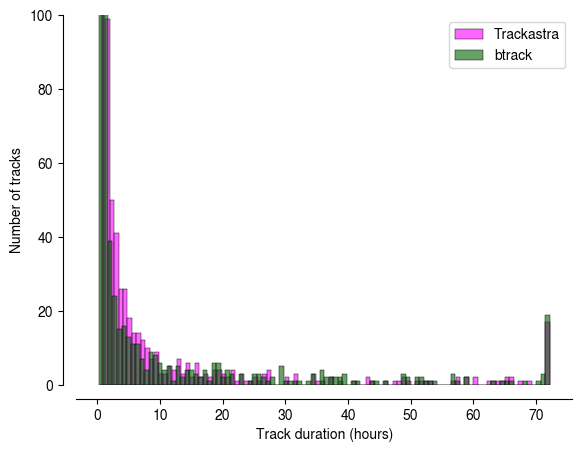

In [82]:
sns.histplot(tracks.groupby('ID').size() * 0.25, color='magenta', bins=100, label='Trackastra', alpha = 0.6)
sns.histplot(btracks.groupby('ID').size() * 0.25, color='darkgreen', bins=100, label='btrack', alpha = 0.6)
plt.legend()
plt.xlabel('Track duration (hours)')
plt.ylabel('Number of tracks')
plt.ylim(0,100)
sns.despine(offset=10)
plt.savefig('/mnt/DATA2/VP0001/labels/pos_15/dev/btrackastra_length_comparison.pdf', bbox_inches ='tight', dpi = 314)

In [84]:
pd.DataFrame.to_csv

<function pandas.core.generic.NDFrame.to_csv(self, path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None, *, sep: 'str' = ',', na_rep: 'str' = '', float_format: 'str | Callable | None' = None, columns: 'Sequence[Hashable] | None' = None, header: 'bool_t | list[str]' = True, index: 'bool_t' = True, index_label: 'IndexLabel | None' = None, mode: 'str' = 'w', encoding: 'str | None' = None, compression: 'CompressionOptions' = 'infer', quoting: 'int | None' = None, quotechar: 'str' = '"', lineterminator: 'str | None' = None, chunksize: 'int | None' = None, date_format: 'str | None' = None, doublequote: 'bool_t' = True, escapechar: 'str | None' = None, decimal: 'str' = '.', errors: 'OpenFileErrors' = 'strict', storage_options: 'StorageOptions | None' = None) -> 'str | None'>

In [87]:
tracks.to_csv('/mnt/DATA2/VP0001/labels/pos_15/dev/trackastra/tracks.csv', index=False)

In [14]:
import pandas as pd

In [15]:
tracks = pd.read_csv('/mnt/DATA2/VP0001/labels/pos_15/dev/trackastra/tracks.csv')

In [32]:
tracks

,ID,t,z,y,x
0,1.0,0.0,16.797165,274.576416,574.737427
1,1.0,1.0,16.098774,270.456635,576.396912
2,1.0,2.0,15.791374,273.498688,573.241516
3,1.0,3.0,15.765885,277.548981,574.386230
4,1.0,4.0,15.915837,279.359253,569.098145
...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210
24635,744.0,110.0,15.352196,1000.230713,843.508484
24636,744.0,111.0,14.553087,1000.190125,848.523010
24637,744.0,112.0,15.079845,1001.858337,847.549927


## Now measure the expression of fluorescence markers across ALL DIMENSIONS

In [16]:
images.shape, segmentation.shape

((289, 3, 32, 1024, 1024), (289, 32, 1024, 1024))

In [122]:
masks_tracked.shape

(289, 32, 1024, 1024)

In [97]:
tracks.round()

,ID,t,z,y,x
0,1.0,0.0,17.0,275.0,575.0
1,1.0,1.0,16.0,270.0,576.0
2,1.0,2.0,16.0,273.0,573.0
3,1.0,3.0,16.0,278.0,574.0
4,1.0,4.0,16.0,279.0,569.0
...,...,...,...,...,...
24634,744.0,109.0,15.0,1001.0,840.0
24635,744.0,110.0,15.0,1000.0,844.0
24636,744.0,111.0,15.0,1000.0,849.0
24637,744.0,112.0,15.0,1002.0,848.0


In [114]:
for i, row in tracks.round().astype(int).iterrows():
    break

In [117]:
row

ID      1
t       0
z      17
y     275
x     575
Name: 0, dtype: int64

In [121]:
segmentation_ID = segmentation[row['t'], row['z'], row['y'], row['x']]

20

In [118]:
images[row['t'], :, row['z'], row['y'], row['x']]


array([  0,   0, 131], dtype=uint8)

# Otsu segmentation for mtb quantification

In [17]:
images.shape

(289, 3, 32, 1024, 1024)

In [18]:
mtb_channel = np.max(images[:,0:2,...], axis = 1)

In [19]:
mtb_channel.shape

(289, 32, 1024, 1024)

In [129]:
viewer.add_image(mtb_channel, name = 'mtb')

<Image layer 'mtb' at 0x7f9c93bfc100>

In [52]:
from skimage.filters import median, threshold_multiotsu


In [132]:
img = mtb_channel[0,15,...]

In [143]:
thresholds = threshold_multiotsu(img)

In [144]:
thresholds

array([ 6, 42])

In [141]:
regions = np.digitize(img, bins=thresholds)

In [142]:
viewer.add_image(regions)

<Image layer 'regions [1]' at 0x7f9c2cd8e980>

In [160]:
thresholded = (img >= 42).astype(np.uint8)

In [161]:
viewer.add_image(thresholded)

<Image layer 'thresholded [4]' at 0x7f9c2c878f10>

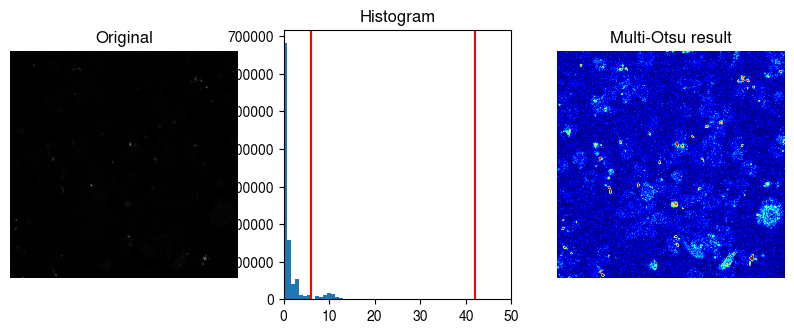

In [157]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(img.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')
ax[1].set_xlim(0,50)

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()

In [165]:
mtb_channel.shape

(289, 32, 1024, 1024)

In [166]:
mtb_channel[0].shape

(32, 1024, 1024)

In [168]:
thresholds = threshold_multiotsu(mtb_channel[0])
thresholds

array([ 6, 58])

In [169]:
regions  = np.digitize(mtb_channel[0], bins=thresholds)
regions.shape

(32, 1024, 1024)

In [170]:
viewer.add_image(regions)

<Image layer 'regions [1]' at 0x7f9c2e488dc0>

### Iterate over frames applying otsu segmentation

In [29]:
threshold_values

array([ 6, 58])

In [ ]:
thresholded_mtb = np.empty_like(mtb_channel)
for i, mtb_frame in tqdm(enumerate(mtb_channel), total = len(mtb_channel)):
    threshold_values = threshold_multiotsu(mtb_frame)
    thresholded_mtb_frame = median((mtb_frame > threshold_values[-1]).astype(np.uint8))
    thresholded_mtb[i] = thresholded_mtb_frame

  0%|          | 0/289 [00:00<?, ?it/s]

In [58]:
# viewer = napari.Viewer(title = 'testing mtb thresholding')
viewer.add_image(thresholded_mtb)

<Image layer 'thresholded_mtb [2]' at 0x7f11241ff850>

In [55]:
test = median(thresholded_mtb_frame)

In [56]:
viewer.add_image(test)

<Image layer 'test' at 0x7f13bad73760>

In [40]:
tracks

,ID,t,z,y,x
0,1.0,0.0,16.797165,274.576416,574.737427
1,1.0,1.0,16.098774,270.456635,576.396912
2,1.0,2.0,15.791374,273.498688,573.241516
3,1.0,3.0,15.765885,277.548981,574.386230
4,1.0,4.0,15.915837,279.359253,569.098145
...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210
24635,744.0,110.0,15.352196,1000.230713,843.508484
24636,744.0,111.0,14.553087,1000.190125,848.523010
24637,744.0,112.0,15.079845,1001.858337,847.549927


In [83]:
x_scale, y_scale, z_scale = 1/3.52, 1/3.52, 1/2.499581800737184
voxel_volume_um3 = x_scale * y_scale * z_scale

In [84]:
voxel_volume_um3

0.032288459055149404

In [86]:
tracks

,ID,t,z,y,x,mtb_volume
0,1.0,0.0,16.797165,274.576416,574.737427,None
1,1.0,1.0,16.098774,270.456635,576.396912,None
2,1.0,2.0,15.791374,273.498688,573.241516,None
3,1.0,3.0,15.765885,277.548981,574.386230,None
4,1.0,4.0,15.915837,279.359253,569.098145,None
...,...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210,None
24635,744.0,110.0,15.352196,1000.230713,843.508484,None
24636,744.0,111.0,14.553087,1000.190125,848.523010,None
24637,744.0,112.0,15.079845,1001.858337,847.549927,None


In [94]:
track_timepoint

ID      1
t       0
z      17
y     275
x     575
Name: 0, dtype: int64

In [151]:
voxel_volume_um3

0.032288459055149404

In [159]:
# tracks['mtb_volume'] = np.zeros(len(tracks), dtype=int)
# tracks['cell_volume'] = np.zeros(len(tracks), dtype=int)
# tracks['green'] = np.zeros(len(tracks), dtype=int)
# tracks['red'] = np.zeros(len(tracks), dtype=int)

for i, track_timepoint in tqdm(tracks.round().astype(int).iterrows(), total = len(tracks)):
    t, z, y, x = track_timepoint['t'], track_timepoint['z'], track_timepoint['y'], track_timepoint['x'] 
    segment_ID = segmentation[t, z, y, x]
    segment = (segmentation[t] == segment_ID).astype(bool) 
    sc_mtb_load = segment * thresholded_mtb[t]
    n_voxels = np.count_nonzero(sc_mtb_load)
    tracks.loc[i, 'mtb_volume'] = n_voxels * voxel_volume_um3
    tracks.loc[i, 'cell_volume'] = np.count_nonzero(segment)
    green_frame = images[t, 0, ...]
    green = np.mean(sc_mtb_load * green_frame)
    red_frame = images[t, 1, ...]
    red = np.mean(sc_mtb_load * red_frame)
    tracks.loc[i, 'green'] = green
    tracks.loc[i, 'red'] = red


  0%|          | 0/24639 [00:00<?, ?it/s]

In [152]:
viewer.add_labels(thresholded_mtb)


<Labels layer 'thresholded_mtb' at 0x7f1154740040>

In [141]:
segmentation.shape

(289, 32, 1024, 1024)

In [131]:
viewer.add_labels(segmentation)
viewer.add_image(images, channel_axis=1)

[<Image layer 'Image' at 0x7f13b118da50>,
 <Image layer 'Image [1]' at 0x7f13b0db7310>,
 <Image layer 'Image [2]' at 0x7f13b0c26b30>]

In [169]:
tracks

,ID,t,z,y,x,mtb_volume,green,red,cell_volume
0,1.0,0.0,16.797165,274.576416,574.737427,0.000000,0.000000,0.00000,164415
1,1.0,1.0,16.098774,270.456635,576.396912,0.000000,0.000000,0.00000,154747
2,1.0,2.0,15.791374,273.498688,573.241516,0.000000,0.000000,0.00000,156093
3,1.0,3.0,15.765885,277.548981,574.386230,0.096865,0.000004,0.00001,147842
4,1.0,4.0,15.915837,279.359253,569.098145,0.000000,0.000000,0.00000,151361
...,...,...,...,...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210,0.000000,0.000000,0.00000,115154
24635,744.0,110.0,15.352196,1000.230713,843.508484,0.000000,0.000000,0.00000,133582
24636,744.0,111.0,14.553087,1000.190125,848.523010,0.000000,0.000000,0.00000,87724
24637,744.0,112.0,15.079845,1001.858337,847.549927,0.000000,0.000000,0.00000,78477


In [171]:
tracks.iloc[:, :5].values

array([[1.00000000e+00, 0.00000000e+00, 1.67971649e+01, 2.74576416e+02,
        5.74737427e+02],
       [1.00000000e+00, 1.00000000e+00, 1.60987740e+01, 2.70456635e+02,
        5.76396912e+02],
       [1.00000000e+00, 2.00000000e+00, 1.57913742e+01, 2.73498688e+02,
        5.73241516e+02],
       ...,
       [7.44000000e+02, 1.11000000e+02, 1.45530872e+01, 1.00019012e+03,
        8.48523010e+02],
       [7.44000000e+02, 1.12000000e+02, 1.50798454e+01, 1.00185834e+03,
        8.47549927e+02],
       [7.44000000e+02, 1.13000000e+02, 1.54014273e+01, 1.00411450e+03,
        8.38077820e+02]])

In [172]:
viewer.add_tracks(tracks.iloc[:, :5].values)

<Tracks layer 'Tracks' at 0x7f13b42abfd0>

Rendering frames...


100%|██████████████████████████████████████████████████████████████████████████████████| 46/46 [00:11<00:00,  3.97it/s]


Rendering frames...


100%|████████████████████████████████████████████████████████████████████████████████| 219/219 [00:45<00:00,  4.84it/s]


Rendering frames...


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:50<00:00,  5.24it/s]
Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/napari_animation/_qt/frame_widget.py", line 66, in _update_animation_ease
    active_keyframe.ease = self.get_easing_func()
AttributeError: 'NoneType' object has no attribute 'ease'
Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/napari_animation/_qt/frame_widget.py", line 66, in _update_animation_ease
    active_keyframe.ease = self.get_easing_func()
AttributeError: 'NoneType' object has no attribute 'ease'


Rendering frames...


100%|████████████████████████████████████████████████████████████████████████████████| 219/219 [00:43<00:00,  5.03it/s]


In [130]:
images.shape

(289, 3, 32, 1024, 1024)

In [166]:
tracks.to_csv('/mnt/DATA2/VP0001/labels/pos_15/dev/tracks_gr.csv')

In [121]:
tracks[tracks['mtb_volume'] > 130]

,ID,t,z,y,x,mtb_volume,green,red,cell_volume
9008,152.0,0.0,18.285177,510.067902,214.660126,131.220298,0.004401,0.014444,643280


In [164]:
filtered_tracks = tracks.groupby('ID').filter(lambda x: len(x) > 240)

In [162]:
tracks[(tracks['t'] ==20) & (tracks['mtb_volume'] >0)]

,ID,t,z,y,x,mtb_volume,green,red,cell_volume
20,1.0,20.0,15.718966,273.714508,568.061768,0.387462,1.579523e-05,0.000040,157618
140,2.0,20.0,16.171858,127.440353,95.342430,2.324769,5.581975e-05,0.000182,309431
278,3.0,20.0,15.624242,581.387268,417.060608,0.032288,8.940697e-07,0.000002,172100
527,7.0,20.0,15.494893,490.909180,731.783813,0.774923,2.601743e-05,0.000074,177224
1725,13.0,20.0,16.135134,919.358704,196.828644,3.293423,7.614493e-05,0.000236,162728
2590,29.0,20.0,17.690561,1005.056396,226.229141,5.489038,1.366735e-04,0.000400,76810
2887,42.0,20.0,16.035601,599.993225,127.943672,18.727306,6.115139e-04,0.001761,218981
3193,47.0,20.0,18.989832,348.955109,897.325684,5.166153,1.578331e-04,0.000582,139065
3400,49.0,20.0,15.842138,350.836426,556.971313,0.064577,6.258488e-07,0.000006,143866
3996,73.0,20.0,15.693705,90.531464,286.714050,1.937308,3.889203e-05,0.000148,412135


In [127]:
segmentation.shape

(289, 32, 1024, 1024)

In [124]:
import seaborn as sns

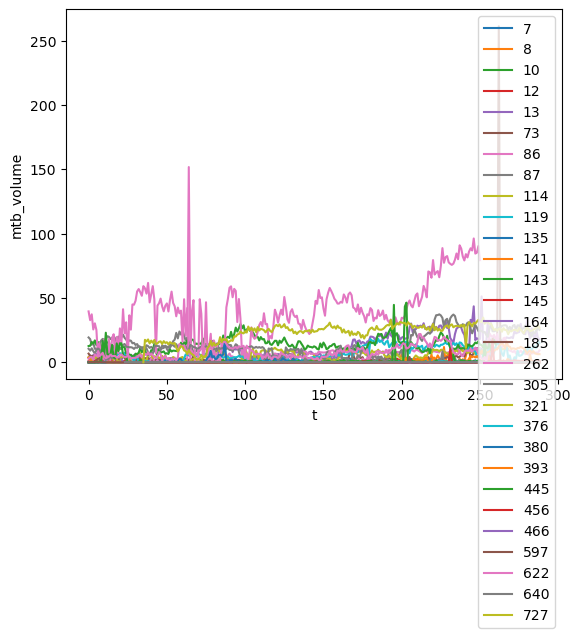

In [165]:
for ID, sc_df in filtered_tracks.groupby('ID'):
    x = sc_df['t']
    y = sc_df['mtb_volume']
    sns.lineplot(x=x, y=y, label=int(ID))
    

In [77]:
sc_mtb_load.shape

(32, 1024, 1024)

In [75]:
viewer.add_labels(sc_mtb_load)

<Labels layer 'sc_mtb_load' at 0x7f13c8f504f0>

In [ ]:
 # 'dims_n': {1: 1024, 2: 1024, 3: 27, 4: 289},
 # 'scale_n': {1: 3.52, 2: 3.52, 3: 2.499581800737184, 4: 0.0011109246712067999},
anisotropy = 2.499581800737184 / 3.52 